In [1]:
import pandas as pd
import glob
import os

ordner = "/content/Daten"
dateien = glob.glob(os.path.join(ordner, "*.csv"))

df_liste = []

for datei in dateien:
    df_temp = pd.read_csv(datei, engine="python", on_bad_lines="skip", sep=";")
    df_temp["quelle_datei"] = os.path.basename(datei)
    df_liste.append(df_temp)

df = pd.concat(df_liste, ignore_index=True)

print(df.head())
print(df.info())

           english_term         spanish_term  migrationsbezug_eng  \
0  Acquired citizenship  Ciudadanía Derivada                    1   
1  Acquired citizenship  Ciudadanía Derivada                    1   
2  Acquired citizenship  Ciudadanía Derivada                    1   
3  Acquired citizenship  Ciudadanía Derivada                    1   
4  Acquired citizenship  Ciudadanía Derivada                    1   

   migrationsbezug_spa  polysemie_eng  polysemie_spa  topic_number  \
0                    1              0              0             1   
1                    1              0              0             1   
2                    1              0              0             1   
3                    1              0              0             1   
4                    1              0              0             1   

                               topic  migrationsbezug_equal  \
0  Rechtlicher Status und Aufenthalt                      1   
1  Rechtlicher Status und Aufenthalt  

In [2]:
clean_df = df[
    ~(
        (
            (df['qs_eng'].notna() & df['qs_migrationsbezug_eng_final'].isna()) |
            (df['qs_spa'].notna() & df['qs_migrationsbezug_spa_final'].isna())
        )
        |
        (df['english_term'] == "Naturalization certificate")
        |
         (df['english_term'] == "Petitioner")
        |
         (df['english_term'] == "Smuggling of migrants")
        |
         (df['english_term'] == "foreigner")

    )
].copy()

In [3]:
terms_eng_df = clean_df[['english_term', 'polysemie_eng', 'migrationsbezug_eng']].drop_duplicates()

In [4]:
terms_spa_df = clean_df[['spanish_term', 'polysemie_spa', 'migrationsbezug_spa']].drop_duplicates()

In [5]:
print("Anzahl Terme:", len(terms_eng_df))
print("Polysem (1):", terms_eng_df['polysemie_eng'].sum())
print("Nicht polysem (0):", (terms_eng_df['polysemie_eng'] == 0).sum())

print("Anteil polysem:", terms_eng_df['polysemie_eng'].mean())

Anzahl Terme: 331
Polysem (1): 177
Nicht polysem (0): 154
Anteil polysem: 0.5347432024169184


In [6]:
print("Anzahl Terme:", len(terms_spa_df))
print("Polysem (1):", terms_spa_df['polysemie_spa'].sum())
print("Nicht polysem (0):", (terms_spa_df['polysemie_spa'] == 0).sum())

print("Anteil polysem:", terms_spa_df['polysemie_spa'].mean())

Anzahl Terme: 331
Polysem (1): 176
Nicht polysem (0): 155
Anteil polysem: 0.5317220543806647


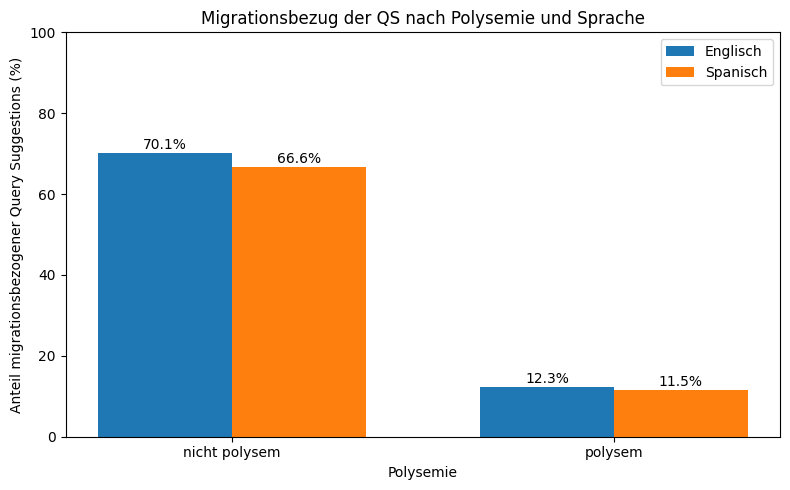

In [7]:
# ============================================================
# BASIC PLOT:
# Migrationsbezug der Query Suggestions nach Polysemie
# getrennt nach Sprache (Englisch vs. Spanisch)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Ausgangsbasis
# ------------------------------------------------------------
df = clean_df.copy()

# ------------------------------------------------------------
# ENGLISCH
# ------------------------------------------------------------

# Nur vorhandene und gelabelte englische QS
df_eng = df[
    (df['qs_eng'].notna()) &
    (df['qs_migrationsbezug_eng_final'].notna())
].copy()

# Anteil migrationsbezogener QS für:
# 0 = nicht polysem
# 1 = polysem
eng_grouped = (
    df_eng.groupby('polysemie_eng')['qs_migrationsbezug_eng_final']
    .mean()
    .mul(100)
)

# ------------------------------------------------------------
# SPANISCH
# ------------------------------------------------------------

df_spa = df[
    (df['qs_spa'].notna()) &
    (df['qs_migrationsbezug_spa_final'].notna())
].copy()

spa_grouped = (
    df_spa.groupby('polysemie_spa')['qs_migrationsbezug_spa_final']
    .mean()
    .mul(100)
)

# ------------------------------------------------------------
# Sicherstellen, dass beide Gruppen existieren (0 und 1)
# ------------------------------------------------------------
eng_grouped = eng_grouped.reindex([0, 1])
spa_grouped = spa_grouped.reindex([0, 1])

# Labels verständlicher machen
labels = ['nicht polysem', 'polysem']

# ------------------------------------------------------------
# Werte extrahieren
# ------------------------------------------------------------
values_eng = eng_grouped.values
values_spa = spa_grouped.values

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, values_eng, width, label='Englisch')
plt.bar(x + width/2, values_spa, width, label='Spanisch')

plt.xticks(x, labels)
plt.ylabel('Anteil migrationsbezogener Query Suggestions (%)')
plt.xlabel('Polysemie')
plt.ylim(0, 100)
plt.title('Migrationsbezug der QS nach Polysemie und Sprache')
plt.legend()

# Prozentwerte anzeigen
for i, v in enumerate(values_eng):
    if pd.notna(v):
        plt.text(i - width/2, v + 1, f"{v:.1f}%", ha='center')

for i, v in enumerate(values_spa):
    if pd.notna(v):
        plt.text(i + width/2, v + 1, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()

In [8]:
pd.crosstab(
    terms_eng_df['polysemie_eng'],
    terms_eng_df['migrationsbezug_eng']
)

migrationsbezug_eng,0,1
polysemie_eng,,
0,20,134
1,158,19


In [9]:
pd.crosstab(
    terms_spa_df['polysemie_spa'],
    terms_spa_df['migrationsbezug_spa']
)

migrationsbezug_spa,0,1
polysemie_spa,,
0,23,132
1,155,21


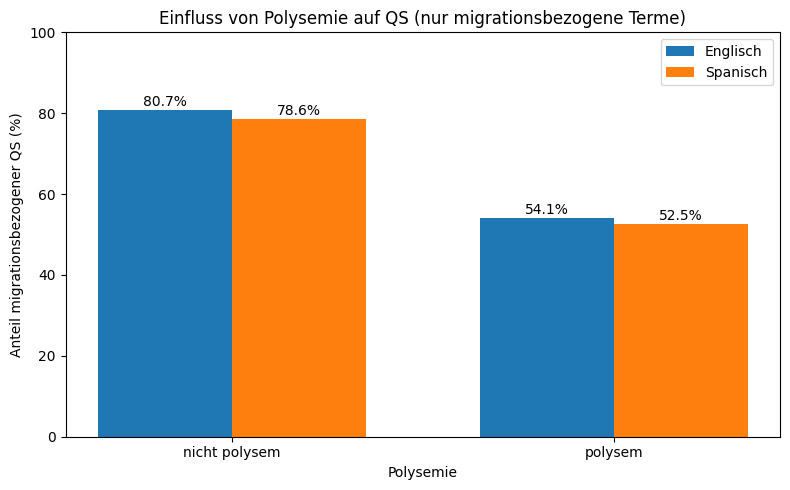

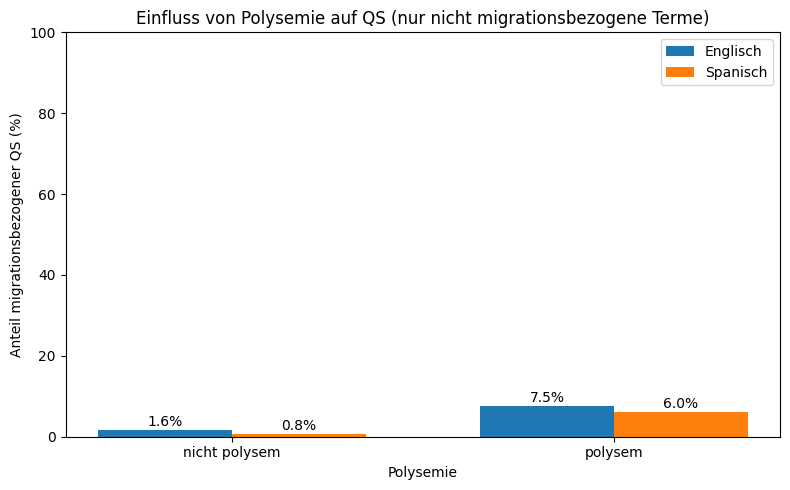

In [10]:
# ============================================================
# FUNKTION:
# Plot für Einfluss von Polysemie unter Kontrolle von Migration
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_polysemie_effect(df, migration_value, title):

    # ------------------------------------------------------------
    # ENGLISCH
    # ------------------------------------------------------------
    subset_eng = df[
        (df['migrationsbezug_eng'] == migration_value) &
        (df['qs_eng'].notna()) &
        (df['qs_migrationsbezug_eng_final'].notna())
    ]

    eng = (
        subset_eng.groupby('polysemie_eng')['qs_migrationsbezug_eng_final']
        .mean()
        .mul(100)
        .reindex([0,1])
    )

    # ------------------------------------------------------------
    # SPANISCH
    # ------------------------------------------------------------
    subset_spa = df[
        (df['migrationsbezug_spa'] == migration_value) &
        (df['qs_spa'].notna()) &
        (df['qs_migrationsbezug_spa_final'].notna())
    ]

    spa = (
        subset_spa.groupby('polysemie_spa')['qs_migrationsbezug_spa_final']
        .mean()
        .mul(100)
        .reindex([0,1])
    )

    # ------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------
    labels = ['nicht polysem', 'polysem']
    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(8,5))

    plt.bar(x - width/2, eng.values, width, label='Englisch')
    plt.bar(x + width/2, spa.values, width, label='Spanisch')

    plt.xticks(x, labels)
    plt.ylabel('Anteil migrationsbezogener QS (%)')
    plt.xlabel('Polysemie')
    plt.ylim(0,100)
    plt.title(title)
    plt.legend()

    # Werte anzeigen
    for i, v in enumerate(eng.values):
        if pd.notna(v):
            plt.text(i - width/2, v + 1, f"{v:.1f}%", ha='center')

    for i, v in enumerate(spa.values):
        if pd.notna(v):
            plt.text(i + width/2, v + 1, f"{v:.1f}%", ha='center')

    plt.tight_layout()
    plt.show()


# ============================================================
# PLOT 1: migrationsbezogene TERME
# ============================================================
plot_polysemie_effect(
    clean_df,
    migration_value=1,
    title='Einfluss von Polysemie auf QS (nur migrationsbezogene Terme)'
)

# ============================================================
# PLOT 2: NICHT migrationsbezogene TERME
# ============================================================
plot_polysemie_effect(
    clean_df,
    migration_value=0,
    title='Einfluss von Polysemie auf QS (nur nicht migrationsbezogene Terme)'
)

In [11]:
import pandas as pd
import numpy as np
from itertools import combinations
import matplotlib.pyplot as plt

# Wir arbeiten auf dem partiell bereinigten Datensatz
df = clean_df.copy()

# Optional: nur Zeilen mit vorhandenen englischen QS
df_en = df[df['qs_eng'].notna()].copy()
df_es = df[df['qs_spa'].notna()].copy()

# Standort-ID bauen
df_en['location_id'] = (
    df_en['land'].astype(str) + " | " +
    df_en['bundesstaat'].astype(str) + " | " +
    df_en['stadt'].astype(str)
)

# Standort-ID bauen
df_es['location_id'] = (
    df_es['land'].astype(str) + " | " +
    df_es['bundesstaat'].astype(str) + " | " +
    df_es['stadt'].astype(str)
)

def jaccard_similarity(set_a, set_b):
    """
    Jaccard-Index zwischen zwei Mengen.
    """
    if not set_a and not set_b:
        return np.nan
    union = set_a | set_b
    if len(union) == 0:
        return np.nan
    return len(set_a & set_b) / len(union)

In [12]:
# Pro Term und Standort die Menge der englischen Query Suggestions
term_location_sets = (
    df_en.groupby(['english_term', 'location_id'])['qs_eng']
    .apply(lambda x: set(x.dropna().astype(str).str.strip()))
    .reset_index(name='qs_set')
)

print(term_location_sets.head())

# Spanische Version
term_location_sets_spa = (
    df_es.groupby(['spanish_term', 'location_id'])['qs_spa']
    .apply(lambda x: set(x.dropna().astype(str).str.strip()))
    .reset_index(name='qs_set')
)

print(term_location_sets_spa.head())

  english_term                                    location_id  \
0     A-Number       Mexiko | Aguascalientes | Aguascalientes   
1     A-Number          Mexiko | Baja California Sur | La Paz   
2     A-Number            Mexiko | Baja California | Mexicali   
3     A-Number  Mexiko | Campeche | San Francisco de Campeche   
4     A-Number            Mexiko | Chiapas | Tuxtla Gutiérrez   

                                              qs_set  
0  {a-number/uscis number, a-number, a-number mea...  
1  {a-number/uscis number, a-number, a-number mea...  
2  {a-number/uscis number, a-number, a-number mea...  
3  {a-number/uscis number, a-number, a-number mea...  
4  {a-number/uscis number, a-number, a-number mea...  
          spanish_term                                    location_id  \
0  Abogado en registro       Mexiko | Aguascalientes | Aguascalientes   
1  Abogado en registro          Mexiko | Baja California Sur | La Paz   
2  Abogado en registro            Mexiko | Baja California |

In [14]:
pairwise_results = []

for term, group in term_location_sets.groupby('english_term'):
    # Liste aller Standort-Sets für diesen Term
    location_sets = list(zip(group['location_id'], group['qs_set']))

    # Nur sinnvoll, wenn es mindestens 2 Standorte gibt
    if len(location_sets) < 2:
        continue

    for (loc1, set1), (loc2, set2) in combinations(location_sets, 2):
        score = jaccard_similarity(set1, set2)
        pairwise_results.append({
            'english_term': term,
            'location_1': loc1,
            'location_2': loc2,
            'jaccard': score
        })

pairwise_df = pd.DataFrame(pairwise_results)
print(pairwise_df.head())

#Spanische Version
pairwise_results_spa = []

for term, group in term_location_sets_spa.groupby('spanish_term'):
    # Liste aller Standort-Sets für diesen Term
    location_sets_spa = list(zip(group['location_id'], group['qs_set']))

    # Nur sinnvoll, wenn es mindestens 2 Standorte gibt
    if len(location_sets_spa) < 2:
        continue

    for (loc1, set1), (loc2, set2) in combinations(location_sets_spa, 2):
        score_spa = jaccard_similarity(set1, set2)
        pairwise_results_spa.append({
            'spanish_term': term,
            'location_1': loc1,
            'location_2': loc2,
            'jaccard': score_spa
        })

pairwise_df_spa = pd.DataFrame(pairwise_results_spa)
print(pairwise_df_spa.head())


  english_term                                location_1  \
0     A-Number  Mexiko | Aguascalientes | Aguascalientes   
1     A-Number  Mexiko | Aguascalientes | Aguascalientes   
2     A-Number  Mexiko | Aguascalientes | Aguascalientes   
3     A-Number  Mexiko | Aguascalientes | Aguascalientes   
4     A-Number  Mexiko | Aguascalientes | Aguascalientes   

                                      location_2  jaccard  
0          Mexiko | Baja California Sur | La Paz      1.0  
1            Mexiko | Baja California | Mexicali      1.0  
2  Mexiko | Campeche | San Francisco de Campeche      1.0  
3            Mexiko | Chiapas | Tuxtla Gutiérrez      1.0  
4                 Mexiko | Chihuahua | Chihuahua      1.0  
          spanish_term                                location_1  \
0  Abogado en registro  Mexiko | Aguascalientes | Aguascalientes   
1  Abogado en registro  Mexiko | Aguascalientes | Aguascalientes   
2  Abogado en registro  Mexiko | Aguascalientes | Aguascalientes   
3  Abog

In [15]:
#Polysemie der Suchbegriffe an DF hängen
pairwise_df = pairwise_df.merge(
    terms_eng_df[['english_term', 'polysemie_eng']],
    on='english_term',
    how='left'
)
pairwise_df_spa = pairwise_df_spa.merge(
    terms_spa_df[['spanish_term', 'polysemie_spa']],
    on='spanish_term',
    how='left'
)

In [16]:
pairwise_df['sprache'] = 'Englisch'
pairwise_df_spa['sprache'] = 'Spanisch'

In [17]:
pairwise_df = pairwise_df.rename(columns={'polysemie_eng': 'polysemie'})
pairwise_df_spa = pairwise_df_spa.rename(columns={'polysemie_spa': 'polysemie'})

In [20]:
combined_df = pd.concat([pairwise_df, pairwise_df_spa], ignore_index=True)
combined_df['polysemie_label'] = combined_df['polysemie'].map({
    0: 'nicht polysem',
    1: 'polysem'
})

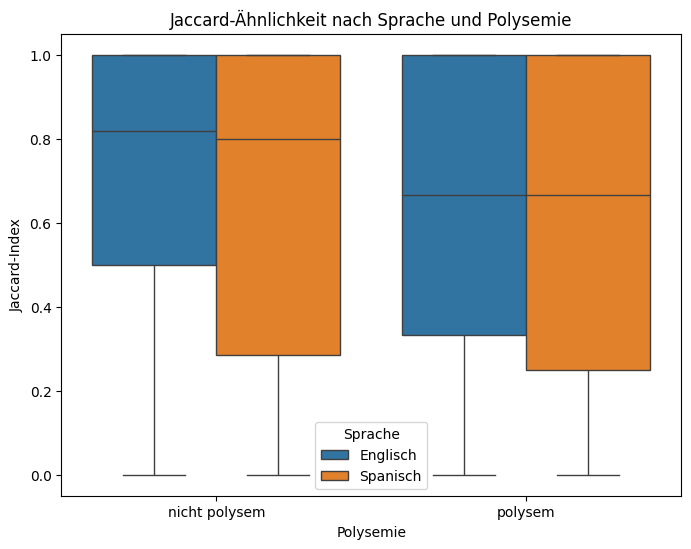

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=combined_df,
    x='polysemie_label',
    y='jaccard',
    hue='sprache'
)

plt.title("Jaccard-Ähnlichkeit nach Sprache und Polysemie")
plt.ylabel("Jaccard-Index")
plt.xlabel("Polysemie")

plt.legend(title="Sprache")
plt.show()

In [26]:
combined_df.groupby(['sprache', 'polysemie_label'])['jaccard'].agg(['mean', 'median'])

mean    median
sprache  polysemie_label                    
Englisch nicht polysem    0.738224  0.818182
         polysem          0.617719  0.666667
Spanisch nicht polysem    0.640674  0.800000
         polysem          0.614143  0.666667